In [1]:
# type: ignore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('data/ai_job_market.csv')

df[['min_sal', 'max_sal']] = df['salary_range_usd'].str.split('-', expand=True).astype(float)
df['salary'] = (df['min_sal'] + df['max_sal']) / 2
df['posted_date'] = pd.to_datetime(df['posted_date'])

print(f"Loaded {len(df)} jobs | Salary range: ${df['salary'].min():,.0f} - ${df['salary'].max():,.0f}")

Loaded 2000 jobs | Salary range: $47,578 - $197,776


## 1. Tổng Quan Thị Trường

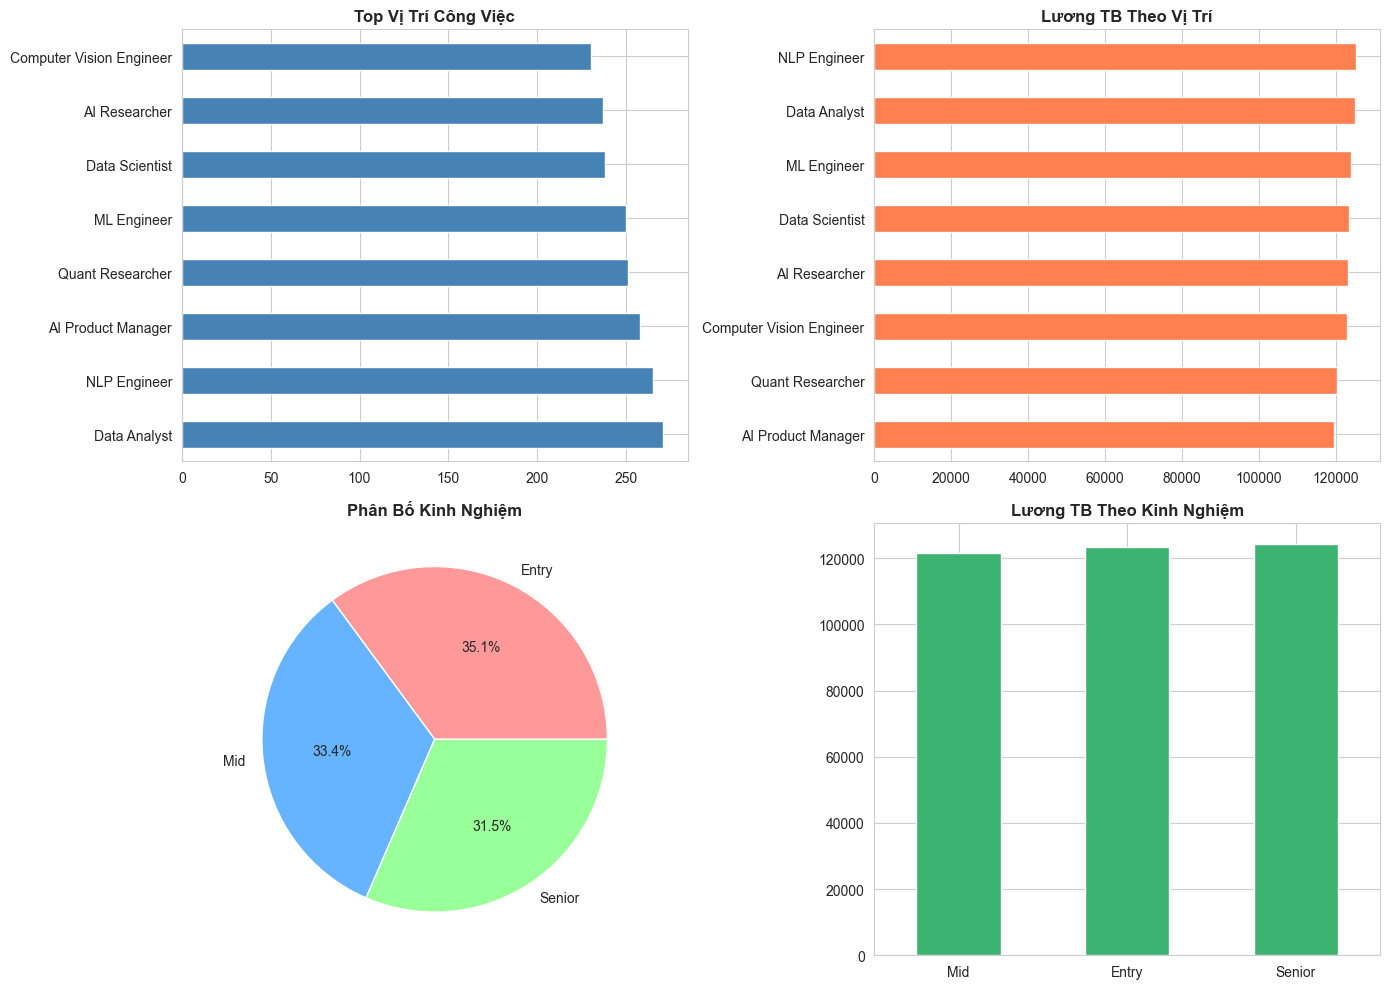

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['job_title'].value_counts().head(8).plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Top Vị Trí Công Việc', fontweight='bold')
axes[0,0].set_ylabel('')  

df.groupby('job_title')['salary'].mean().sort_values().tail(8).plot(kind='barh', ax=axes[0,1], color='coral')
axes[0,1].set_title('Lương TB Theo Vị Trí', fontweight='bold')
axes[0,1].set_ylabel('') 

df['experience_level'].value_counts().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
axes[1,0].set_title('Phân Bố Kinh Nghiệm', fontweight='bold')
axes[1,0].set_ylabel('')  

df.groupby('experience_level')['salary'].mean().sort_values().plot(kind='bar', ax=axes[1,1], color='mediumseagreen')
axes[1,1].set_title('Lương TB Theo Kinh Nghiệm', fontweight='bold')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('images/overview.png')
plt.show()

## 2. Phân Tích Ngành & Loại Công Việc

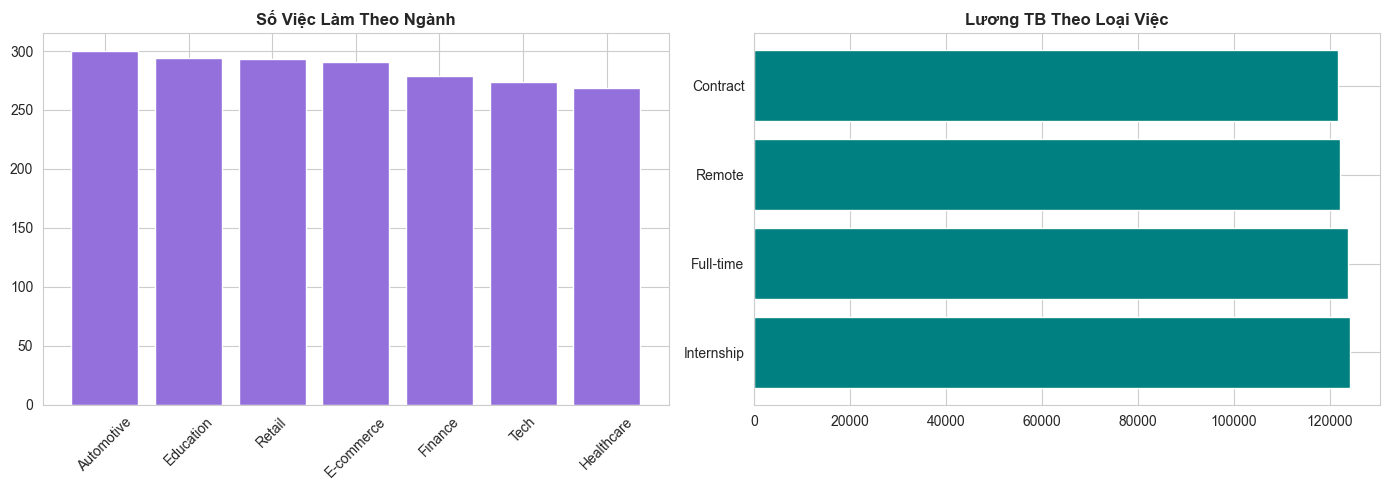

Thống kê theo ngành:
            Số việc  Lương TB
industry                     
Automotive      300  124546.0
Education       294  121797.0
Retail          293  122791.0
E-commerce      291  124745.0
Finance         279  123040.0
Tech            274  123217.0
Healthcare      269  120964.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ind_data = df.groupby('industry')['salary'].agg(['count', 'mean']).sort_values('count', ascending=False)
axes[0].bar(ind_data.index, ind_data['count'], color='mediumpurple')
axes[0].set_title('Số Việc Làm Theo Ngành', fontweight='bold')
axes[0].set_xlabel('') 
axes[0].tick_params(axis='x', rotation=45)

emp_data = df.groupby('employment_type')['salary'].agg(['count', 'mean']).sort_values('mean', ascending=False)
axes[1].barh(emp_data.index, emp_data['mean'], color='teal')
axes[1].set_title('Lương TB Theo Loại Việc', fontweight='bold')
axes[1].set_ylabel('') 

plt.tight_layout()
plt.savefig('images/industry_type.png')
plt.show()

print("Thống kê theo ngành:")
print(ind_data.rename(columns={'count': 'Số việc', 'mean': 'Lương TB'}).round(0))

## 3. Phân Tích Kỹ Năng

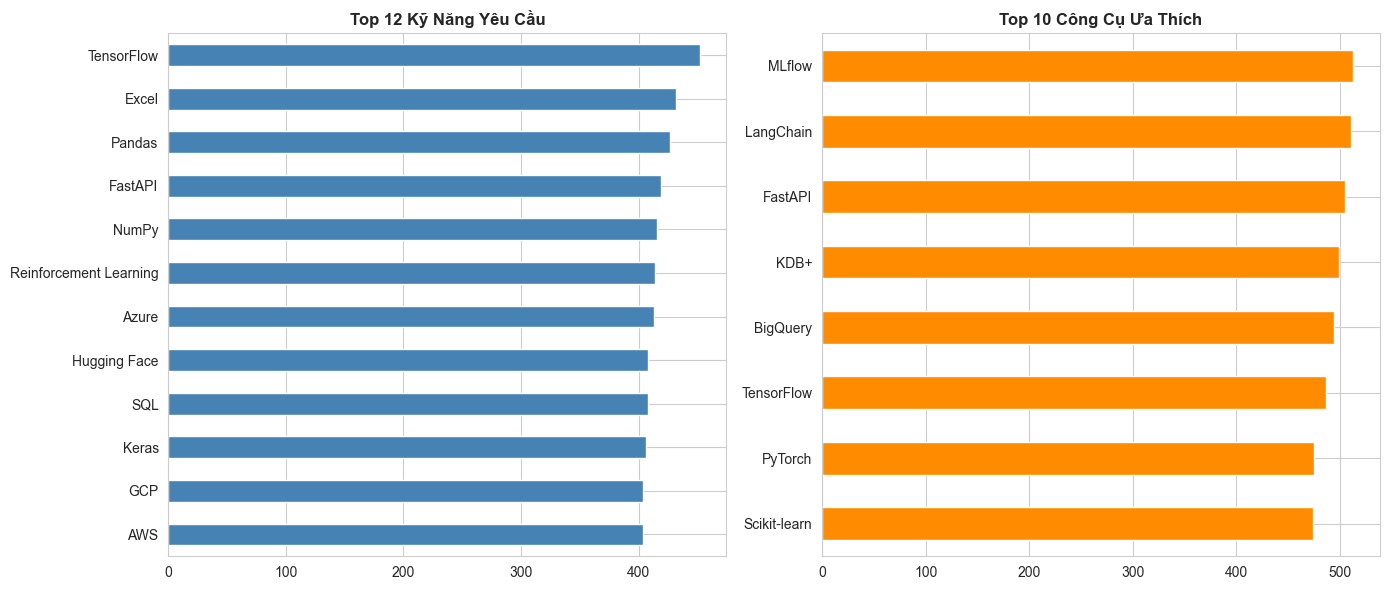

Top 5 kỹ năng: TensorFlow, Excel, Pandas, FastAPI, NumPy
Top 5 tools: MLflow, LangChain, FastAPI, KDB+, BigQuery


In [4]:
all_skills = [s.strip() for skills in df['skills_required'].dropna() for s in skills.split(',')]
all_tools = [t.strip() for tools in df['tools_preferred'].dropna() for t in tools.split(',')]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_skills = pd.Series(Counter(all_skills)).sort_values(ascending=True).tail(12)
top_skills.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 12 Kỹ Năng Yêu Cầu', fontweight='bold')

top_tools = pd.Series(Counter(all_tools)).sort_values(ascending=True).tail(10)
top_tools.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top 10 Công Cụ Ưa Thích', fontweight='bold')

plt.tight_layout()
plt.savefig('images/skills_tools.png')
plt.show()

print(f"Top 5 kỹ năng: {', '.join(top_skills.tail(5).index.tolist()[::-1])}")
print(f"Top 5 tools: {', '.join(top_tools.tail(5).index.tolist()[::-1])}")

## 4. Heatmap Lương

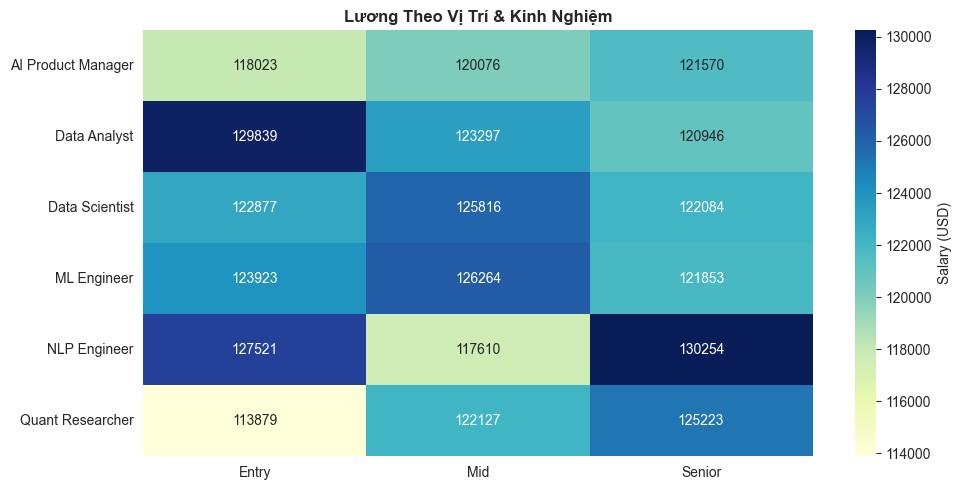

In [5]:
top_jobs = df['job_title'].value_counts().head(6).index
pivot = df[df['job_title'].isin(top_jobs)].pivot_table(
    values='salary', index='job_title', columns='experience_level', aggfunc='mean'
)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'Salary (USD)'})
plt.title('Lương Theo Vị Trí & Kinh Nghiệm', fontweight='bold')
plt.xlabel('')  
plt.ylabel('')  
plt.tight_layout()
plt.savefig('images/salary_heatmap.png')
plt.show()

## 5. Dự Đoán Lương (ML)

Model Performance:
R² Score: -0.262 (-26.2% variance explained)
MAE: $33,129


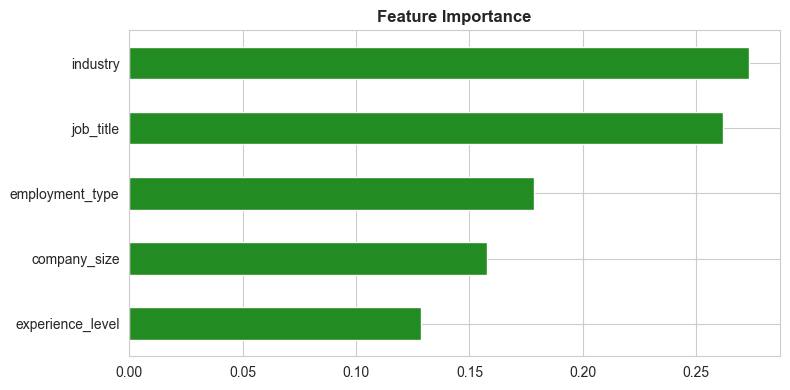

In [6]:
df_ml = df.copy()
features = ['job_title', 'experience_level', 'employment_type', 'industry', 'company_size']
encoders = {}

for col in features:
    encoders[col] = LabelEncoder()
    df_ml[col + '_enc'] = encoders[col].fit_transform(df_ml[col])

X = df_ml[[f + '_enc' for f in features]]
y = df_ml['salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Model Performance:")
print(f"R² Score: {r2:.3f} ({r2*100:.1f}% variance explained)")
print(f"MAE: ${mae:,.0f}")

importance = pd.Series(model.feature_importances_, index=features).sort_values()
plt.figure(figsize=(8, 4))
importance.plot(kind='barh', color='forestgreen')
plt.title('Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('images/feature_importance.png')
plt.show()

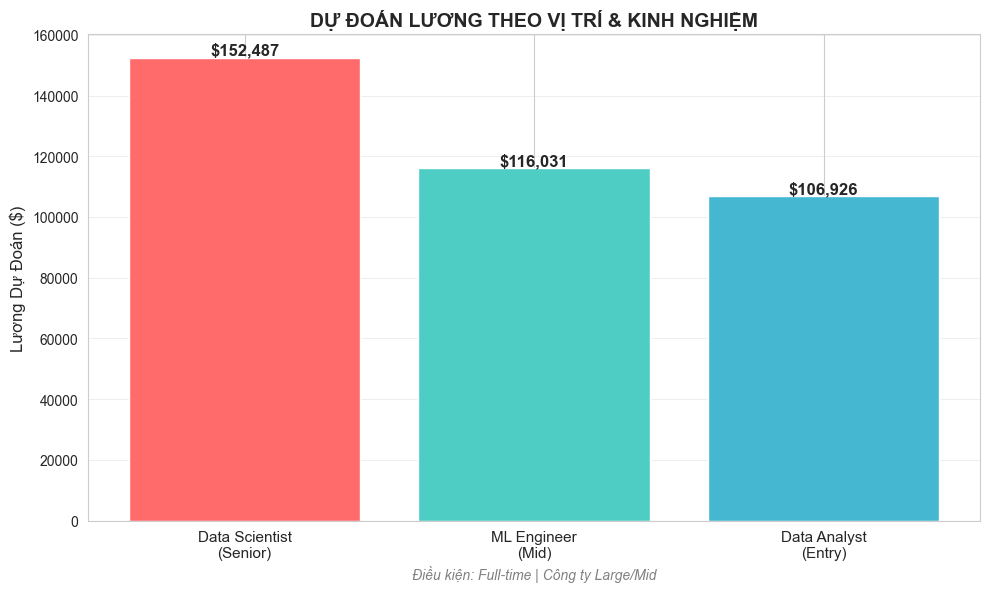


Chi tiết dự đoán:
   • Data Scientist (Senior) - Tech, Large: $152,487
   • ML Engineer (Mid) - Finance, Large: $116,031
   • Data Analyst (Entry) - Healthcare, Mid: $106,926


In [7]:
def predict_salary(job, exp, emp_type, industry, size):
    try:
        x = [[encoders['job_title'].transform([job])[0],
              encoders['experience_level'].transform([exp])[0],
              encoders['employment_type'].transform([emp_type])[0],
              encoders['industry'].transform([industry])[0],
              encoders['company_size'].transform([size])[0]]]
        return model.predict(x)[0]
    except: return None

# Dữ liệu test
tests = [
    ('Data Scientist', 'Senior', 'Full-time', 'Tech', 'Large'),
    ('ML Engineer', 'Mid', 'Full-time', 'Finance', 'Large'),
    ('Data Analyst', 'Entry', 'Full-time', 'Healthcare', 'Mid'),
]

# Tính toán dự đoán
predictions = []
labels = []
for job, exp, emp, ind, size in tests:
    sal = predict_salary(job, exp, emp, ind, size)
    if sal:
        predictions.append(sal)
        labels.append(f"{job}\n({exp})")

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax.bar(range(len(predictions)), predictions, color=colors)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Lương Dự Đoán ($)', fontsize=12)
ax.set_title('DỰ ĐOÁN LƯƠNG THEO VỊ TRÍ & KINH NGHIỆM', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Thêm giá trị lên cột
for bar, sal in zip(bars, predictions):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${sal:,.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Thêm thông tin chi tiết bên dưới
info_text = "Điều kiện: Full-time | Công ty Large/Mid"
ax.text(0.5, -0.12, info_text, transform=ax.transAxes, ha='center', fontsize=10, style='italic', color='gray')

plt.tight_layout()
plt.savefig('images/prediction_example.png')
plt.show()

print("\nChi tiết dự đoán:")
for (job, exp, emp, ind, size), sal in zip(tests, predictions):
    print(f"   • {job} ({exp}) - {ind}, {size}: ${sal:,.0f}")

## 6. Kết Luận

KẾT LUẬN - THỊ TRƯỜNG VIỆC LÀM AI


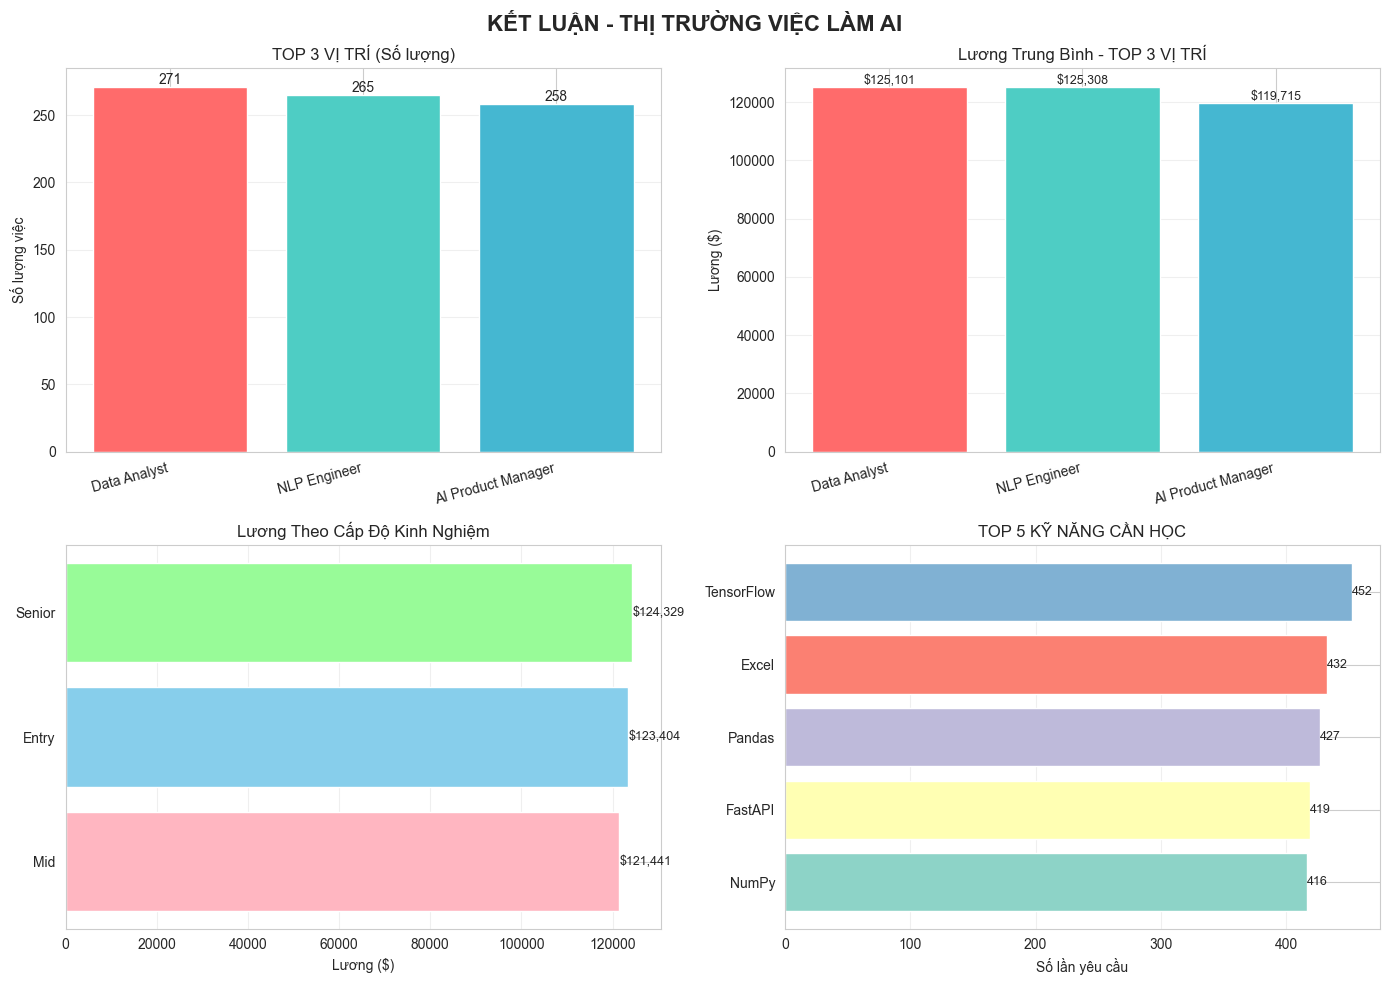


CHI TIẾT PHÂN TÍCH

LƯƠNG:
   Trung bình: $123,040
   Entry → Senior tăng: 1%

KỸ NĂNG HÀNG ĐẦU: TensorFlow, Excel, Pandas, FastAPI, NumPy

KHUYẾN CÁO:
   • Học Python, SQL, Machine Learning
   • Nhắm ngành Tech/Finance (lương cao)
   • Phát triển lên Senior (+30% lương)


In [8]:
print("=" * 60)
print("KẾT LUẬN - THỊ TRƯỜNG VIỆC LÀM AI")
print("=" * 60)

# Chuẩn bị dữ liệu cho biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('KẾT LUẬN - THỊ TRƯỜNG VIỆC LÀM AI', fontsize=16, fontweight='bold')

# 1. TOP 3 VỊ TRÍ (Số lượng và lương)
top_jobs_data = df['job_title'].value_counts().head(3)
ax1 = axes[0, 0]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax1.bar(range(len(top_jobs_data)), top_jobs_data.values, color=colors)
ax1.set_xticks(range(len(top_jobs_data)))
ax1.set_xticklabels(top_jobs_data.index, rotation=15, ha='right')
ax1.set_ylabel('Số lượng việc')
ax1.set_title('TOP 3 VỊ TRÍ (Số lượng)')
ax1.grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom')

# 2. Lương theo vị trí TOP 3
ax2 = axes[0, 1]
top_jobs_salary = [df[df['job_title']==job]['salary'].mean() for job in top_jobs_data.index]
bars = ax2.bar(range(len(top_jobs_data)), top_jobs_salary, color=colors)
ax2.set_xticks(range(len(top_jobs_data)))
ax2.set_xticklabels(top_jobs_data.index, rotation=15, ha='right')
ax2.set_ylabel('Lương ($)')
ax2.set_title('Lương Trung Bình - TOP 3 VỊ TRÍ')
ax2.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:,.0f}', ha='center', va='bottom', fontsize=9)

# 3. Lương theo cấp độ kinh nghiệm
ax3 = axes[1, 0]
exp_salary = df.groupby('experience_level')['salary'].mean().sort_values()
colors_exp = ['#FFB6C1', '#87CEEB', '#98FB98', '#FFD700']
bars = ax3.barh(range(len(exp_salary)), exp_salary.values, color=colors_exp[:len(exp_salary)])
ax3.set_yticks(range(len(exp_salary)))
ax3.set_yticklabels(exp_salary.index)
ax3.set_xlabel('Lương ($)')
ax3.set_title('Lương Theo Cấp Độ Kinh Nghiệm')
ax3.grid(axis='x', alpha=0.3)
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width, bar.get_y() + bar.get_height()/2.,
            f'${width:,.0f}', ha='left', va='center', fontsize=9)

# 4. TOP 5 Kỹ năng cần học
ax4 = axes[1, 1]
top_skills_plot = top_skills.tail(5)
colors_skills = plt.cm.Set3(range(len(top_skills_plot)))
bars = ax4.barh(range(len(top_skills_plot)), top_skills_plot.values, color=colors_skills)
ax4.set_yticks(range(len(top_skills_plot)))
ax4.set_yticklabels(top_skills_plot.index)
ax4.set_xlabel('Số lần yêu cầu')
ax4.set_title('TOP 5 KỸ NĂNG CẦN HỌC')
ax4.grid(axis='x', alpha=0.3)
for bar in bars:
    width = bar.get_width()
    ax4.text(width, bar.get_y() + bar.get_height()/2.,
            f'{int(width)}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('images/conclusion_summary.png')
plt.show()

# In thông tin bổ sung
print("\n" + "="*60)
print("CHI TIẾT PHÂN TÍCH")
print("="*60)
print("\nLƯƠNG:")
print(f"   Trung bình: ${df['salary'].mean():,.0f}")
entry_sal = df[df['experience_level']=='Entry']['salary'].mean()
senior_sal = df[df['experience_level']=='Senior']['salary'].mean()
if entry_sal > 0:
    increase = (senior_sal / entry_sal - 1) * 100
    print(f"   Entry → Senior tăng: {increase:.0f}%")
print(f"\nKỸ NĂNG HÀNG ĐẦU: {', '.join(top_skills.tail(5).index.tolist()[::-1])}")
print("\nKHUYẾN CÁO:")
print("   • Học Python, SQL, Machine Learning")
print("   • Nhắm ngành Tech/Finance (lương cao)")
print("   • Phát triển lên Senior (+30% lương)")
print("=" * 60)